In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
# File paths
Races      = "Nemo.csv"
Forcedeck       = "Forcedeck.csv"
Commit   = "Commit.csv"

In [12]:
# Column names — race dataset
RACE_ATHLETE_COL  = "AthleteName"
RACE_DATE_COL     = "Date"
RACE_EVENT_COL    = "RaceEventName"
RACE_DISTANCE_COL = "RaceEventDistance"
RACE_POOL_COL     = "PoolLength"
MEET_COL     = "CompetitionName"        
sex = "AthleteGenderName"
T15_COL           = "Lap1_15mElapsedTime"

# Column names — CMJ dataset
CMJ_ATHLETE_COL   = "About"     # adjust if different
CMJ_DATE_COL      = "Date"
CMJ_TYPE_COL      = "Test Type"
CMJ_HEIGHT_COL    = "Jump Height (Flight Time) [cm]"

# Filter values
CMJ_TEST_TYPE     = "CMJ"
MATCH_TOLERANCE   = pd.Timedelta("90D")
MIN_GROUP_SIZE    = 3
START_DATE        = "2023-10-01"

# Distances and strokes to analyse
DISTANCES = [50, 100]
STROKES   = ["Freestyle", "Backstroke", "Breaststroke", "Butterfly"]

# Plotting colours per stroke
STROKE_COLORS = { "Freestyle":    "#2E86AB",
    "Backstroke":   "#E84855",
    "Breaststroke": "#F4A261",
    "Butterfly":    "#57CC99",}

In [4]:
# ── Cell 3: Load data ─────────────────────────────────────────────────────────
races    = pd.read_csv(Races)
cmj      = pd.read_csv(Forcedeck)
athletes = pd.read_csv(Commit)

print(f"Races:    {races.shape}")
print(f"CMJ:      {cmj.shape}")
print(f"Athletes: {athletes.shape}")

Races:    (2837, 762)
CMJ:      (2000, 722)
Athletes: (13810, 173)


In [6]:
#Preprocess race data 

# Normalise athlete names
races[RACE_ATHLETE_COL] = races[RACE_ATHLETE_COL].str.lower().str.strip()

# Parse dates
races[RACE_DATE_COL] = pd.to_datetime(races[RACE_DATE_COL])

# Filter: 50m and 100m events only
races = races[races[RACE_DISTANCE_COL].isin(DISTANCES)]

# Filter: date range
races = races[races[RACE_DATE_COL] >= START_DATE]

# Drop rows with missing T15
races = races.dropna(subset=[T15_COL])

print(f"Races after filtering: {len(races)}")

Races after filtering: 565


In [8]:
#Cell 5: Preprocess CMJ data

# Normalise athlete names
cmj[CMJ_ATHLETE_COL] = cmj[CMJ_ATHLETE_COL].str.lower().str.strip()

# Parse dates
cmj[CMJ_DATE_COL] = pd.to_datetime(cmj[CMJ_DATE_COL], dayfirst=True)

# Filter: CMJ test type only
cmj = cmj[cmj[CMJ_TYPE_COL].str.upper() == CMJ_TEST_TYPE]

# Keep only relevant columns and sort for merge_asof
cmj_clean = cmj[[CMJ_ATHLETE_COL, CMJ_DATE_COL, CMJ_HEIGHT_COL]].sort_values(CMJ_DATE_COL)

print(f"CMJ records after filtering: {len(cmj_clean)}")

CMJ records after filtering: 1722


In [9]:
#Match races to nearest CMJ test (within 90 days)
races_sorted = races.sort_values(RACE_DATE_COL)

matched = pd.merge_asof(
    races_sorted,
    cmj_clean.rename(columns={CMJ_ATHLETE_COL: RACE_ATHLETE_COL,
                               CMJ_DATE_COL:    "cmj_date"}),
    left_on=RACE_DATE_COL,
    right_on="cmj_date",
    by=RACE_ATHLETE_COL,
    direction="nearest",
    tolerance=MATCH_TOLERANCE
)

matched = matched.dropna(subset=[CMJ_HEIGHT_COL])
print(f"Matched race-CMJ pairs: {len(matched)}")

Matched race-CMJ pairs: 301


In [10]:
#Helper — run OLS and neural network with LOOCV

def run_models_loocv(X, y, group_label=""):
    """
    Fits OLS (LinearRegression) and a neural network (MLPRegressor)
    on X -> y using Leave-One-Out Cross-Validation.
    Returns a dict of results.
    """
    X = np.array(X).reshape(-1, 1)
    y = np.array(y)
    loo = LeaveOneOut()

    # ── OLS ──
    ols_preds = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X):
        m = LinearRegression()
        m.fit(X[train_idx], y[train_idx])
        ols_preds[test_idx] = m.predict(X[test_idx])

    ols_r2   = r2_score(y, ols_preds)
    ols_rmse = np.sqrt(mean_squared_error(y, ols_preds))

    # Full-data OLS fit for plotting
    ols_full = LinearRegression().fit(X, y)

    # ── Neural Network ──
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    nn_preds = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X_scaled):
        nn = MLPRegressor(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            max_iter=2000,
            random_state=42
        )
        nn.fit(X_scaled[train_idx], y[train_idx])
        nn_preds[test_idx] = nn.predict(X_scaled[test_idx])

    nn_r2   = r2_score(y, nn_preds)
    nn_rmse = np.sqrt(mean_squared_error(y, nn_preds))

    if group_label:
        print(f"  {group_label}  n={len(y)}")
        print(f"    OLS  — R²: {ols_r2:.3f}  RMSE: {ols_rmse:.3f}s")
        print(f"    NN   — R²: {nn_r2:.3f}  RMSE: {nn_rmse:.3f}s")

    return {
        "n": len(y),
        "ols_r2": ols_r2, "ols_rmse": ols_rmse, "ols_model": ols_full,
        "nn_r2":  nn_r2,  "nn_rmse":  nn_rmse,
        "X": X, "y": y,
    }

In [23]:
#Run models — all strokes, both distances, split by sex ────────────
results = {}

for distance in DISTANCES:
    print(f"\n{'='*50}")
    print(f"  {distance}m events")
    print(f"{'='*50}")
    for stroke in STROKES:
        for sex in ["Men", "Women"]:
            mask = (
                (matched[RACE_DISTANCE_COL] == distance) &
                (matched[RACE_EVENT_COL].str.contains(stroke, case=False, na=False)) &
                (~matched[RACE_EVENT_COL].str.contains("Relay|IM", case=False, na=False)) &
                (matched["AthleteGenderName"] == sex)
            )
            subset = matched[mask].dropna(subset=[CMJ_HEIGHT_COL, T15_COL])

            if len(subset) < MIN_GROUP_SIZE:
                print(f"  {stroke} / {sex} / {distance}m — skipped (n={len(subset)})")
                continue

            label = f"{distance}m {stroke} / {sex}"
            res = run_models_loocv(subset[CMJ_HEIGHT_COL], subset[T15_COL], label)
            results[(distance, stroke, sex)] = res


  50m events
  Freestyle / Men / 50m — skipped (n=2)
  Freestyle / Women / 50m — skipped (n=2)
  Backstroke / Men / 50m — skipped (n=0)


C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and 

  50m Backstroke / Women  n=8
    OLS  — R²: -0.754  RMSE: 0.121s
    NN   — R²: -4533.149  RMSE: 6.171s
  Breaststroke / Men / 50m — skipped (n=0)


C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and 

  50m Breaststroke / Women  n=16
    OLS  — R²: 0.341  RMSE: 0.109s
    NN   — R²: -1822.487  RMSE: 5.743s


...

C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and 

  100m Butterfly / Men  n=13
    OLS  — R²: -0.304  RMSE: 0.198s
    NN   — R²: -499.744  RMSE: 3.879s


C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and 

  100m Butterfly / Women  n=49
    OLS  — R²: 0.231  RMSE: 0.141s
    NN   — R²: -901.057  RMSE: 4.838s


C:\Users\adhamz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


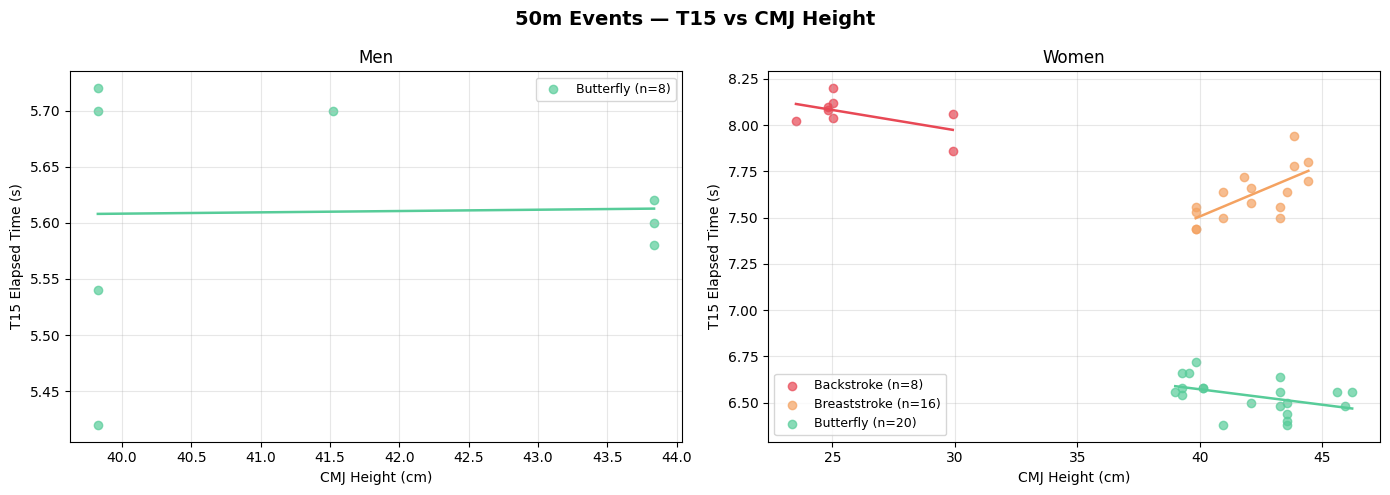

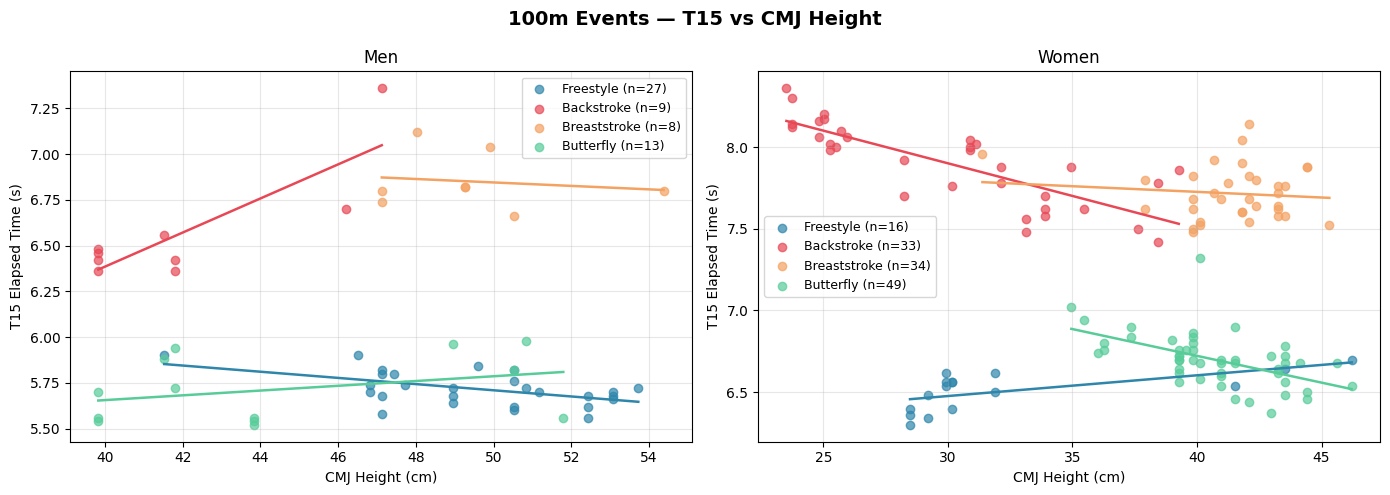

In [24]:
#Plot — OLS regression lines per stroke/sex/distance 

for distance in DISTANCES:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    fig.suptitle(f"{distance}m Events — T15 vs CMJ Height", fontsize=14, fontweight="bold")

    for ax, sex in zip(axes, ["Men", "Women"]):
        ax.set_title(sex)
        ax.set_xlabel("CMJ Height (cm)")
        ax.set_ylabel("T15 Elapsed Time (s)")

        for stroke in STROKES:
            key = (distance, stroke, sex)
            if key not in results:
                continue
            res = results[key]
            X, y = res["X"].flatten(), res["y"]
            color = STROKE_COLORS[stroke]

            # Scatter
            ax.scatter(X, y, color=color, alpha=0.7, label=f"{stroke} (n={res['n']})")

            # OLS regression line
            x_line = np.linspace(X.min(), X.max(), 100)
            y_line = res["ols_model"].predict(x_line.reshape(-1, 1))
            ax.plot(x_line, y_line, color=color, linewidth=1.8)

        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"T15_CMJ_{distance}m.png", dpi=150)
    plt.show()

In [25]:
#Summary table
rows = []
for (distance, stroke, sex), res in results.items():
    rows.append({
        "Distance": f"{distance}m",
        "Stroke":   stroke,
        "Sex":      sex,
        "n":        res["n"],
        "OLS R²":   round(res["ols_r2"],  3),
        "OLS RMSE": round(res["ols_rmse"], 3),
        "NN R²":    round(res["nn_r2"],   3),
        "NN RMSE":  round(res["nn_rmse"],  3),
    })

summary = pd.DataFrame(rows).sort_values(["Distance", "Stroke", "Sex"])
summary

,Distance,Stroke,Sex,n,OLS R²,OLS RMSE,NN R²,NN RMSE
6,100m,Backstroke,Men,9,0.072,0.286,-251.646,4.723
7,100m,Backstroke,Women,33,0.586,0.156,-611.116,6.019
8,100m,Breaststroke,Men,8,-0.446,0.172,-1237.708,5.039
9,100m,Breaststroke,Women,34,-0.190,0.174,-1337.195,5.836
10,100m,Butterfly,Men,13,-0.304,0.198,-499.744,3.879
11,100m,Butterfly,Women,49,0.231,0.141,-901.057,4.838
4,100m,Freestyle,Men,27,0.173,0.081,-1920.670,3.880
5,100m,Freestyle,Women,16,0.256,0.098,-1671.693,4.653
0,50m,Backstroke,Women,8,-0.754,0.121,-4533.149,6.171
1,50m,Breaststroke,Women,16,0.341,0.109,-1822.487,5.743
